In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
data = {
    'weather': ['sunny', 'sunny', 'sunny', 'sunny', 'sunny', 'sunny',
                'raining', 'raining', 'raining', 'raining', 'raining', 'raining'],
    'outcome': ['go out', 'go out', 'go out', 'go out', 'go out', 'go out',
                'stay in', 'stay in', 'stay in', 'stay in', 'stay in', 'stay in']
}
df = pd.DataFrame(data)
df

,weather,outcome
0,sunny,go out
1,sunny,go out
2,sunny,go out
3,sunny,go out
4,sunny,go out
5,sunny,go out
6,raining,stay in
7,raining,stay in
8,raining,stay in
9,raining,stay in


In [3]:
le_weather = LabelEncoder()
df['weather_encoded'] = le_weather.fit_transform(df['weather'])

X = df[['weather_encoded']]
y = df['outcome']

print(dict(zip(le_weather.classes_, le_weather.transform(le_weather.classes_))))

{'raining': np.int64(0), 'sunny': np.int64(1)}


In [4]:
model = DecisionTreeClassifier(criterion='entropy', random_state=5)
model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",5
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

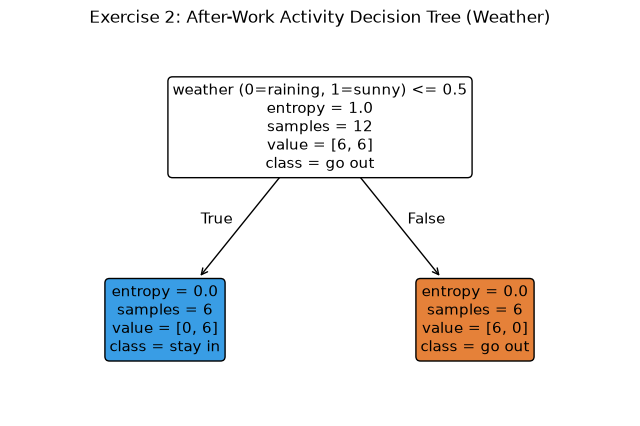

In [5]:
plt.figure(figsize=(8, 5))
plot_tree(model, feature_names=['weather (0=raining, 1=sunny)'],
          class_names=model.classes_,
          filled=True, rounded=True, fontsize=11)
plt.title('Exercise 2: After-Work Activity Decision Tree (Weather)')
plt.show()

In [6]:
test_weather = pd.DataFrame({'weather_encoded': [1, 0]})  # 1=sunny, 0=raining
predictions = model.predict(test_weather)

print('Sunny ->', predictions[0])
print('Raining ->', predictions[1])

Sunny -> go out
Raining -> stay in
